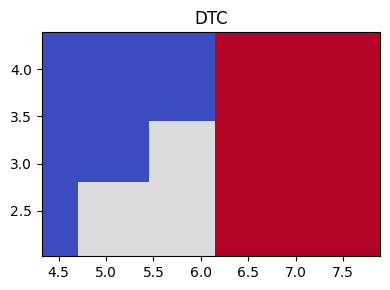

In [1]:
from sklearn import datasets
from sklearn import model_selection as skms
from sklearn import tree
import matplotlib.pyplot as plt
import numpy as np

def plot_boundary(ax, data, tgt, model, dims, grid_step = .01):
    twoD = data[:, list(dims)]
    min_x1, min_x2 = np.min(twoD, axis=0) + 2 * grid_step
    max_x1, max_x2 = np.max(twoD, axis=0) - grid_step
    xs, ys = np.mgrid[min_x1:max_x1:grid_step,
                      min_x2:max_x2:grid_step]
    grid_points = np.c_[xs.ravel(), ys.ravel()]
    preds = model.fit(twoD, tgt).predict(grid_points).reshape(xs.shape)
    ax.pcolormesh(xs,ys,preds,cmap=plt.cm.coolwarm)
    ax.set_xlim(min_x1, max_x1)
    ax.set_ylim(min_x2, max_x2)

iris = datasets.load_iris()
# standard iris dataset
tts = skms.train_test_split(iris.data, iris.target,
test_size=.33, random_state=21)
(iris_train_ftrs, iris_test_ftrs,
iris_train_tgt, iris_test_tgt) = tts

tree_classifiers = {'DTC' : tree.DecisionTreeClassifier(max_depth=3)}
fig, ax = plt.subplots(1,1,figsize=(4,3))
for name, mod in tree_classifiers.items():
  # plot_boundary only uses specified columns
  # [0,1] [sepal len/width] to predict and graph
  plot_boundary(ax, iris.data, iris.target, mod, [0,1])
  ax.set_title(name)
plt.tight_layout()

In [2]:
dtc = tree.DecisionTreeClassifier()
skms.cross_val_score(dtc,
  iris.data, iris.target,
  cv=3, scoring='accuracy') # sorry

array([0.98, 0.92, 0.98])

In [5]:
useclass = 1
tts_1c = skms.train_test_split(iris.data, iris.target==useclass,
                               test_size=.33, random_state = 21)
(iris_1c_train_ftrs, iris_1c_test_ftrs,
 iris_1c_train_tgt,  iris_1c_test_tgt) = tts_1c

iris_1c_tree = (tree.DecisionTreeClassifier()
  .fit(iris_1c_train_ftrs, iris_1c_train_tgt))

In [9]:
%pip install pydotplus

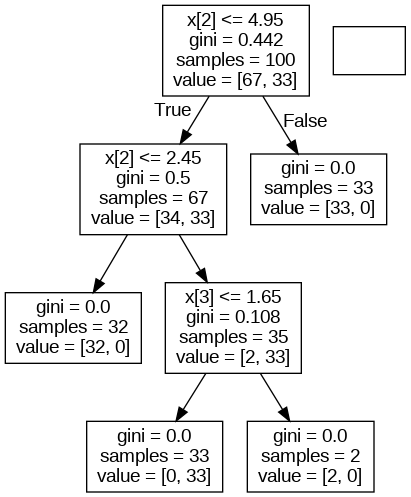

In [13]:
%matplotlib inline
# using an additional library:
# conda install pydotplus
# pip install pydotplus
import pydotplus
from IPython.display import Image

dot_data = tree.export_graphviz(iris_1c_tree, out_file=None)
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png("iris_1c.png")
Image("iris_1c.png", width=500, height=500)

In [14]:
iris_tree = (tree.DecisionTreeClassifier()
  .fit(iris_train_ftrs, iris_train_tgt))

In [17]:
# no added lib. to produce .dot file
with open("iris.dot", 'w') as f:
    dot_data = tree.export_graphviz(iris_tree, out_file=f,
                                    feature_names=iris.feature_names,
                                    class_names=iris.target_names,
                                    filled=True, rounded=True)

# the following '!' lines are "shell" commands
# uses the 'dot' program to convert to dot -> png
!dot -Tpng iris.dot -o iris.png
!rm iris.dot

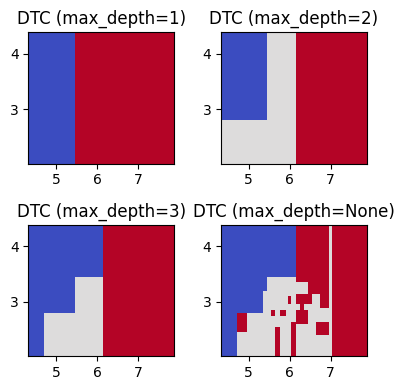

In [18]:
fig, axes = plt.subplots(2,2,figsize=(4,4))

depths = [1, 2, 3, None]
for depth, ax in zip(depths, axes.flat):
    dtc_model = tree.DecisionTreeClassifier(max_depth=depth)
    # plot_boundary only uses specified columns [0,1]
    # so we are only predicting with sepal length and width
    plot_boundary(ax, iris.data, iris.target, dtc_model, [0,1])
    ax.set_title("DTC (max_depth={})".format(dtc_model.max_depth))

plt.tight_layout()